# INFOSCI 301 · Week 3 — Networks and trees
Prof. Luyao Zhang · 8 and 10 September 2026

**Goal:** preserve the data contract while comparing node–link, matrix and tree idioms. Work in rotating groups: driver, task analyst, evidence reviewer. Switch roles after the first comparison. Each person explains one design decision.

This is **constructed teaching data**, not a real citation or transaction network. An undirected binary edge means a documented dependency in this toy example. There are no self-loops.

Reading: Tamara Munzner (2014), *Visualization Analysis and Design*, Chapter 9. [Book and figures](https://www.cs.ubc.ca/~tmm/vadbook/).

## 1. Make the data contract executable
Before running: predict the degree of D and the sum of all degrees. Explain why the latter is twice the number of edges.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
labels = ['Claim','Paper','Code','Dataset','License','Model','Evaluation','User task']
nodes = list('ABCDEFGH')
edges = [('A','B'),('A','G'),('A','H'),('B','C'),('B','D'),('C','D'),('C','F'),('D','E'),('D','F'),('F','G'),('G','H')]
adj = {n: set() for n in nodes}
for a,b in edges:
    assert a != b and a in adj and b in adj
    adj[a].add(b); adj[b].add(a)
assert len({tuple(sorted(e)) for e in edges}) == len(edges)
A = np.array([[int(b in adj[a]) for b in nodes] for a in nodes])
assert np.array_equal(A,A.T) and np.trace(A)==0
assert int(A.sum()) == 2*len(edges)
print('Nodes:', len(nodes), '| Edges:',len(edges))
print('Degrees:',dict(zip(nodes,A.sum(axis=1).tolist())))


Nodes: 8 | Edges: 11
Degrees: {'A': 3, 'B': 3, 'C': 3, 'D': 4, 'E': 1, 'F': 3, 'G': 3, 'H': 2}


## 2. Compare task performance
In pairs, alternate which view you see first. Record time and errors for (a) tracing A–B–D and (b) finding the common neighbors of D and F. This tiny classroom exercise is formative; it does not establish a universal best idiom.

Common neighbors of D and F: ['C']


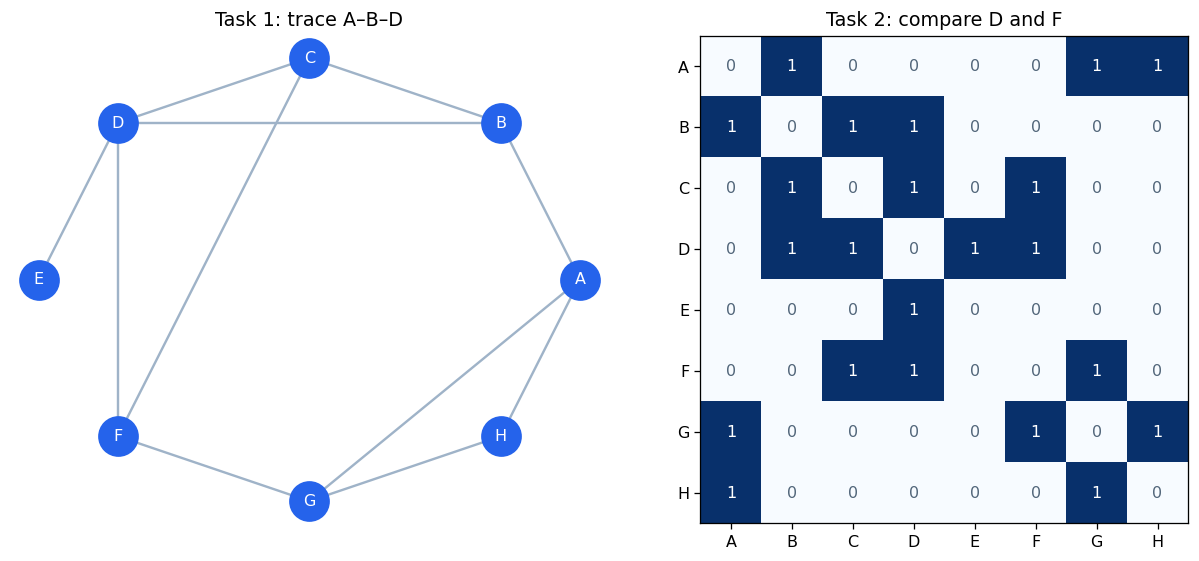

In [2]:
theta = np.arange(len(nodes))*2*np.pi/len(nodes)
pos = dict(zip(nodes,zip(np.cos(theta),np.sin(theta))))
fig,axes = plt.subplots(1,2,figsize=(11,5))
for a,b in edges: axes[0].plot(*zip(pos[a],pos[b]),color='#9fb3c8',zorder=0)
for n in nodes:
    x,y=pos[n];axes[0].scatter(x,y,s=600,color='#2563eb');axes[0].text(x,y,n,ha='center',va='center',color='white')
axes[0].set_title('Task 1: trace A–B–D');axes[0].axis('off')
axes[1].imshow(A,cmap='Blues',vmin=0,vmax=1)
axes[1].set(xticks=range(8),yticks=range(8),xticklabels=nodes,yticklabels=nodes,title='Task 2: compare D and F')
for i in range(8):
    for j in range(8):axes[1].text(j,i,str(A[i,j]),ha='center',va='center',color='white' if A[i,j] else '#52667a')
fig.tight_layout()
print('Common neighbors of D and F:', sorted(adj['D'] & adj['F']))


## 3. Distinguish a network from a derived tree
A spanning tree provides one traversal structure. It discards edges. A natural hierarchy requires a defensible parent–child meaning; a BFS tree does not supply that meaning.

In [3]:
def bfs_tree(root):
    seen={root}; q=deque([root]); result=[]
    while q:
        a=q.popleft()
        for b in sorted(adj[a]):
            if b not in seen:
                seen.add(b); q.append(b); result.append((a,b))
    return result, seen
tree, reached = bfs_tree('A')
assert reached==set(nodes) and len(tree)==len(nodes)-1
lost = {tuple(sorted(e)) for e in edges} - {tuple(sorted(e)) for e in tree}
print('BFS spanning-tree edges:',tree)
print('Omitted original relationships:',sorted(lost))
print('Adjacency matrix bytes:',A.nbytes)


BFS spanning-tree edges: [('A', 'B'), ('A', 'G'), ('A', 'H'), ('B', 'C'), ('B', 'D'), ('G', 'F'), ('D', 'E')]
Omitted original relationships: [('C', 'D'), ('C', 'F'), ('D', 'F'), ('G', 'H')]
Adjacency matrix bytes: 512


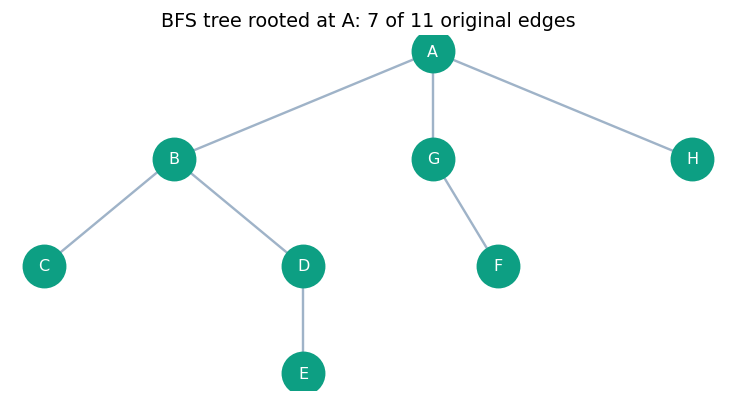

In [4]:
positions={'A':(3,3),'B':(1,2),'G':(3,2),'H':(5,2),'C':(0,1),'D':(2,1),'F':(3.5,1),'E':(2,0)}
fig,ax=plt.subplots(figsize=(8,4))
for a,b in tree:ax.plot(*zip(positions[a],positions[b]),color='#9fb3c8')
for n,(x,y) in positions.items():
    ax.scatter(x,y,s=700,color='#0d9f83',zorder=3);ax.text(x,y,n,ha='center',va='center',color='white',zorder=4)
ax.set_title('BFS tree rooted at A: 7 of 11 original edges');ax.axis('off')


## 4. Redesign challenge
1. Add one node and two documented relationships. Update the contract and rerun the assertions.
2. Give each edge a type. Decide whether a binary matrix still supports the task.
3. Compare a node–link view with a matrix using the **same** node order, data version and task.
4. Record a domain question, data/task decision, idiom decision and algorithm check in your issue.

**Check yourself:** original degree(D)=4; sum(degrees)=22; D and F share C; BFS keeps 7 edges and omits 4. Layout distance is not an edge weight.

AI-Assisted practice: first predict unaided, then use an assistant to explain an error or propose a test. Verify the patch and log your decision. This is practice evidence, not a new weekly reflection.